# Stage 3: Modelling
---

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import config as cf
from src.data_pipeline import load_data, save_data
from src.models import train_test_split, fit_arima, forecast_arima, plot_arima_forecast, evaluate_arima, convert_forecast_to_df


returns_data = load_data('log_returns_data.csv')

Cleaned data loaded successfully.


## ARIMA model:

This model serves as a benchmark however due to ACF plots of log returns fluctuating around zero, we likely will see this model bear poorly with the predictions as it simply does not apply well to data that seems akin to white noise (unpredictable data with no mean and finite variance).

Splitting data at index 1560 (total length: 1590)


/Users/Krish/stock_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/Krish/stock_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


ARIMA evaluation metrics for AMD: {'MSE': 0.0018885863089240296, 'RMSE': np.float64(0.043457868205010124), 'MAE': 0.03349615897373149, 'R-squared': -0.22779058153701315}
Splitting data at index 1560 (total length: 1590)


/Users/Krish/stock_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/Krish/stock_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


ARIMA evaluation metrics for GOOGL: {'MSE': 0.0007104197107480028, 'RMSE': np.float64(0.0266536997572195), 'MAE': 0.01841158620741873, 'R-squared': -0.06633791484297258}
Splitting data at index 1560 (total length: 1590)


/Users/Krish/stock_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/Krish/stock_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


ARIMA evaluation metrics for JPM: {'MSE': 0.0001980609118997488, 'RMSE': np.float64(0.01407341152314352), 'MAE': 0.010670645301278304, 'R-squared': -0.04735272762636433}
Splitting data at index 1560 (total length: 1590)


/Users/Krish/stock_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/Krish/stock_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


ARIMA evaluation metrics for XOM: {'MSE': 0.0003974095262238804, 'RMSE': np.float64(0.019935132962282453), 'MAE': 0.014791901676445722, 'R-squared': -0.0033983334114160435}
Splitting data at index 1560 (total length: 1590)
ARIMA evaluation metrics for KO: {'MSE': 0.00014015895709871472, 'RMSE': np.float64(0.011838874824015782), 'MAE': 0.009166565395068167, 'R-squared': -0.018683190447560838}


/Users/Krish/stock_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/Krish/stock_analysis/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


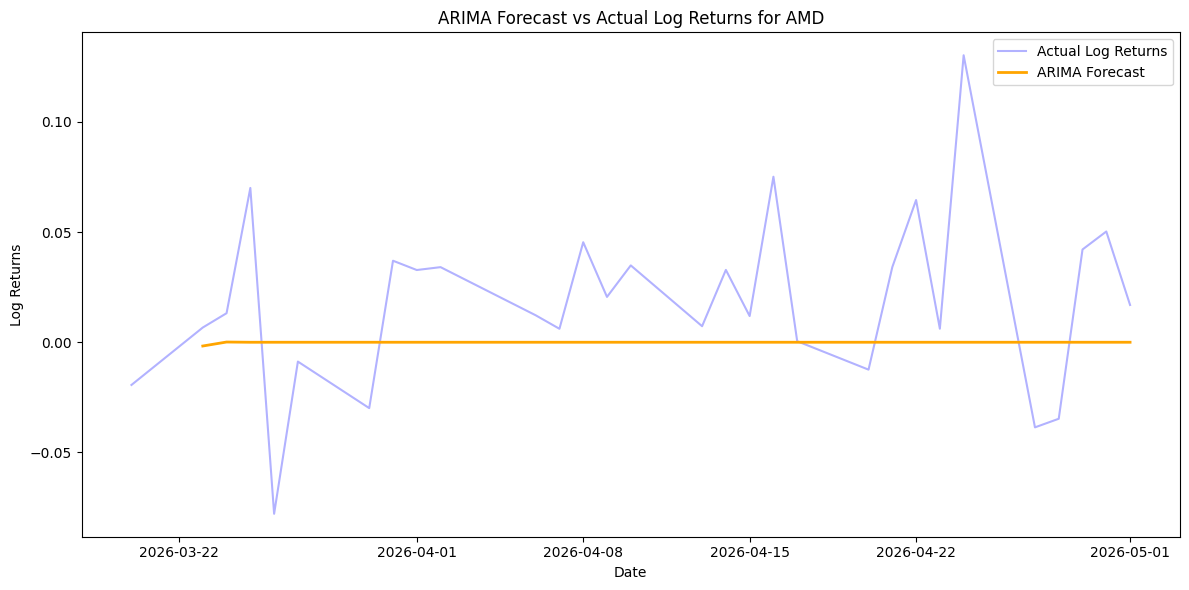

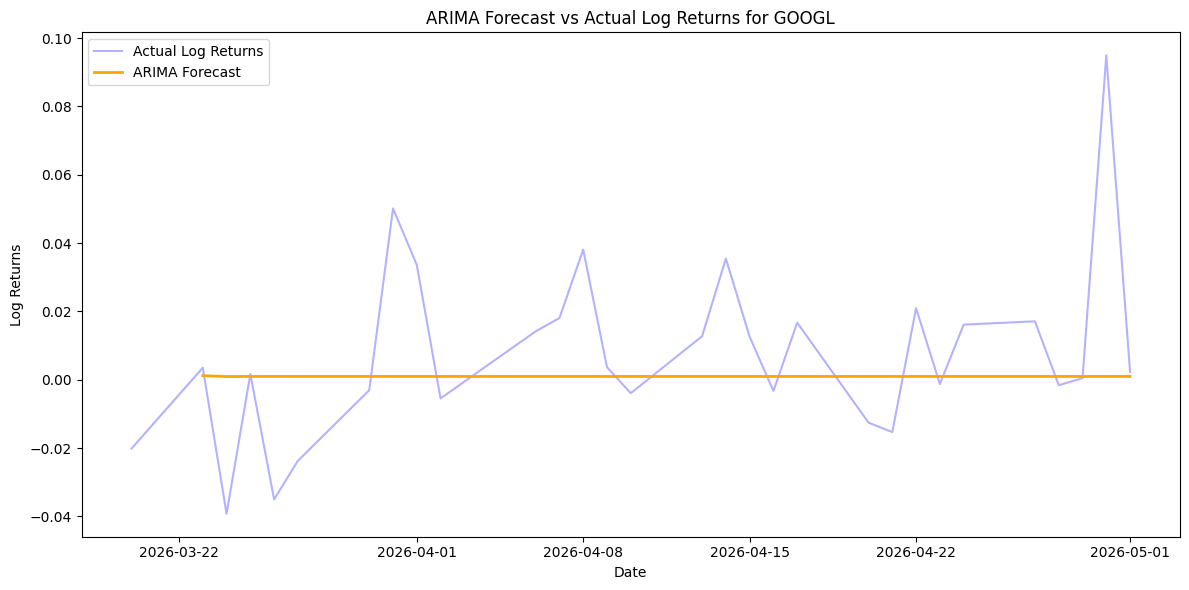

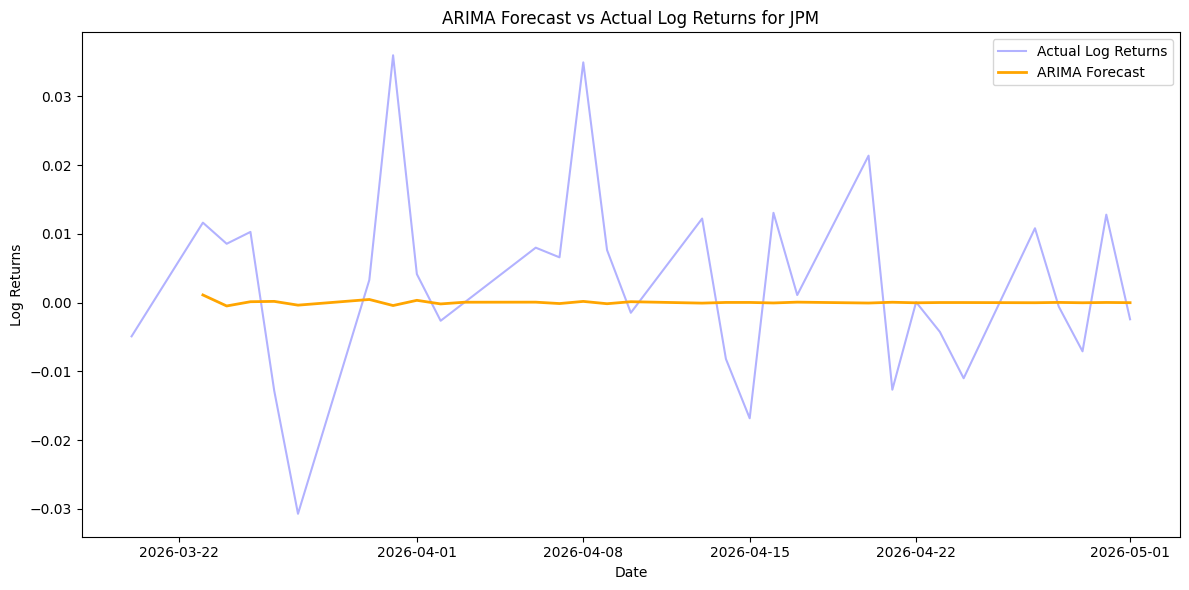

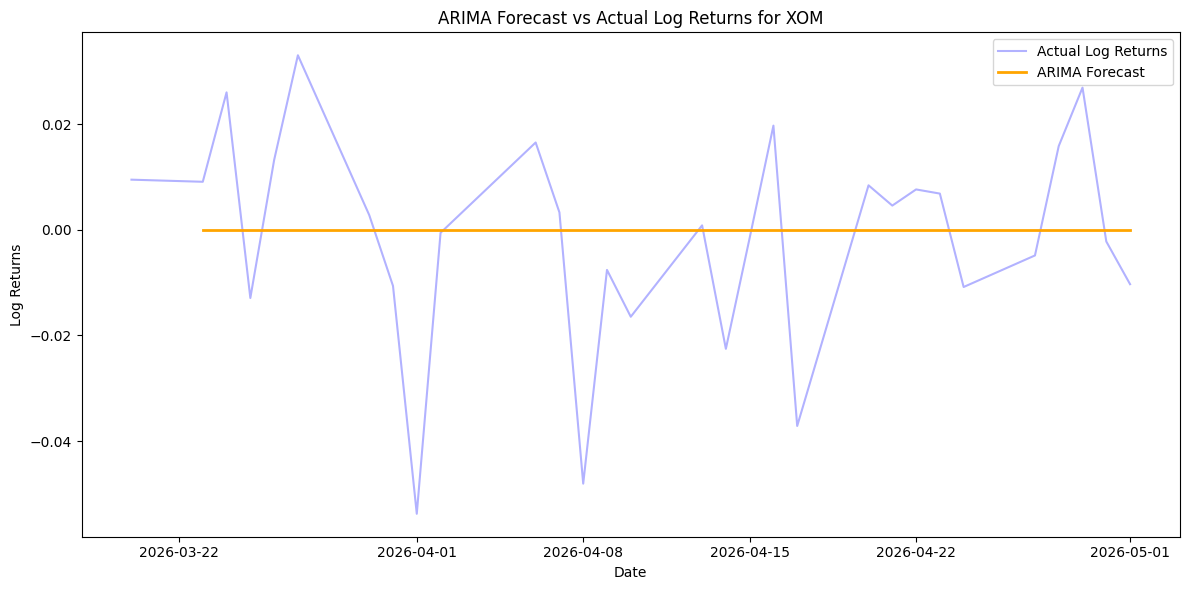

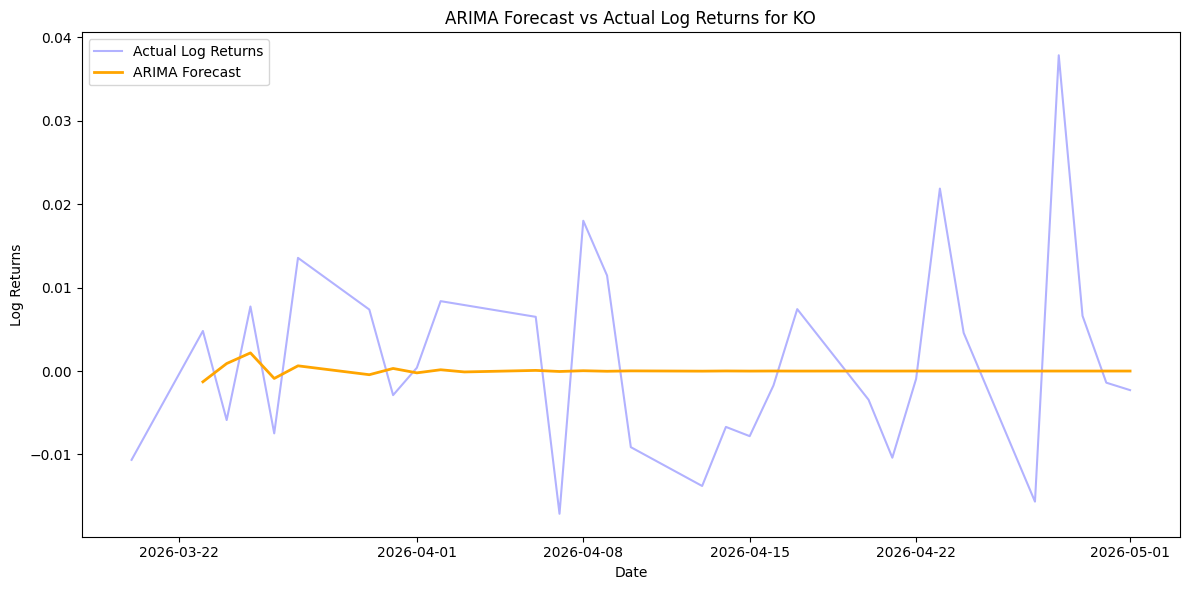

In [2]:
fig_list = []
for stock in cf.SYMBOLS:
    train_data, test_data = train_test_split(returns_data)
    arima_model = fit_arima(train_data, stock)
    forecast_ARIMA = forecast_arima(arima_model)
    forecast_df = convert_forecast_to_df(forecast_ARIMA, returns_data, stock)
    arima_metrics = evaluate_arima(arima_model, forecast_ARIMA, stock, test_data)
    print(f"ARIMA evaluation metrics for {stock}: {arima_metrics}")
    fig = plot_arima_forecast(test_data, forecast_df, stock)
    fig_list.append(fig)

plt.show(fig_list)

As we clearly see the ARIMA model does not predict the noisy nature of the log returns and instead assumes a zero mean with near to no variance except towards the start. As such it is not a good model to use in this scenario due to the white noise like nature of the data. Homeoskedasticity (constant variance) is assumed for ARIMA but it is not the case (as shown in the time series notebook for ACF plots of log returns for each stock). As this assumption does not hold true we must explore heteroskedastic models (ARCH models).

## ARCH Models:

AutoRegressive Conditional Heteroskedasticity models differ from ARIMA models in the sense that ARIMA models of time series based on past values. On the other hand, ARCH models, models volatility of residuals.

GARCH will be the baseline for this test.